 ## Задача

Подготовить исходные данные реестра ОКН Москвы к визуализации в Mapbox GL JS:

1. Загрузить сырой CSV с двухуровневым заголовком
2. Отфильтровать объекты по округу (ЦАО) и типу (здания)
3. Очистить геометрию — распарсить полигоны и центроиды из JSON-строк
4. Стандартизировать категории охраны: федеральный / региональный
5. Экспортировать два GeoJSON-файла:
   - `okn-cao-polygons.geojson` — контуры зданий для слоя заливки
   - `okn-cao-points.geojson` — центроиды для тепловой карты

## Результат

| Файл | Назначение | Записей |
|------|-----------|---------|
| `okn-cao-polygons.geojson` | fill-слой на карте | 2 440 |
| `okn-cao-points.geojson` | heatmap-слой | 2 440 |

# 01 — Очистка данных и экспорт GeoJSON

**Проект:** Moscow Heritage Map — интерактивная карта объектов культурного наследия ЦАО  
**Источник:** data.mos.ru, набор №530  
**Задача:** отфильтровать ЦАО + здания, почистить, экспортировать GeoJSON для Mapbox

In [20]:
import pandas as pd
import geopandas as gpd
import json
import os
from shapely.geometry import shape, mapping

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 80)

## 1. Загрузка сырых данных

In [21]:
raw = pd.read_csv('../raw data/data-530-21-04-2026.csv', sep=';', header=[0, 1])

raw.columns = raw.columns.get_level_values(1)
print(f'Всего записей: {len(raw)}')
raw.head(2)

Всего записей: 6886


,Наименование объекта по документам,Идентификатор в АИС Мосгорнаследия,Номер ЕГРОКН,Общепринятое наименование объекта,Наименование ансамбля по документам,Общепринятое наименование ансамбля,Административный округ,Район,Местоположение объекта,Местоположение объекта,Охранный статус,Категория объекта,Вид объекта недвижимости,global_id,Геоданные,Центроид
0,"Назаровская башня, 1895 г., арх. К.М.Быковский",b249eae3-56f9-11e2-965f-005056806bb6,7.714104e+14,NaN,Обсерватория Московского университета,NaN,Центральный административный округ,Пресненский район,nested data,"Нововаганьковский переулок, дом 5, строение 7",объект культурного наследия,регионального значения,Сооружение,2949468,"{""type"":""MultiPolygon"",""coordinates"":[[[[37.568926109,55.758190958],[37.5689...","{""type"":""Point"",""coordinates"":[37.568970703,55.758188264]}"
1,"Флигель северный, 1770–1780-е гг., 1907 г., архитектор Л.Гравецкий, 1770–178...",ff74c6e7-56f8-11e2-965f-005056806bb6,7.714112e+14,NaN,"Службы городской усадьбы, XVIII – нач. XIX вв.",NaN,Центральный административный округ,Басманный район,nested data,"Токмаков переулок, дом 21/2, строение 2",объект культурного наследия,регионального значения,Здание,2949522,"{""type"":""Polygon"",""coordinates"":[[[37.670863892,55.765827604],[37.671035882,...","{""type"":""Point"",""coordinates"":[37.671012441,55.765775815]}"


## 2. Первичный осмотр

In [22]:
print('Колонки:')
for i, col in enumerate(raw.columns):
    print(f'  [{i}] {col}')

print(f'\nАдминистративные округа: {raw["Административный округ"].nunique()}')
print(f'Виды объектов: {raw["Вид объекта недвижимости"].nunique()}')

Колонки:
  [0] Наименование объекта по документам
  [1] Идентификатор в АИС Мосгорнаследия
  [2] Номер ЕГРОКН
  [3] Общепринятое наименование объекта
  [4] Наименование ансамбля по документам
  [5] Общепринятое наименование ансамбля
  [6] Административный округ
  [7] Район
  [8] Местоположение объекта
  [9] Местоположение объекта
  [10] Охранный статус
  [11] Категория объекта
  [12] Вид объекта недвижимости
  [13] global_id
  [14] Геоданные
  [15] Центроид

Административные округа: 27
Виды объектов: 29


In [23]:
# две колонки называются одинаково — «Местоположение объекта»
# [8] содержит «nested data» (бесполезно), [9] — нормальный адрес
print('Колонка [8]:', raw.iloc[2, 8][:40])
print('Колонка [9]:', raw.iloc[2, 9][:60])

Колонка [8]: nested data
Колонка [9]: переулок Обуха, дом 5, строение 1


## 3. Фильтрация: ЦАО + Здания

В данных 6886 записей по всей Москве. Нас интересуют только здания в Центральном административном округе.

In [24]:
# фильтруем по округу и типу объекта
is_cao = raw['Административный округ'] == 'Центральный административный округ'
is_building = raw['Вид объекта недвижимости'] == 'Здание'

df = raw[is_cao & is_building].copy()
print(f'После фильтрации: {len(df)} записей')
print(f'Категории охраны: {df["Категория объекта"].value_counts().to_dict()}')

После фильтрации: 2439 записей
Категории охраны: {'регионального значения': 1264, 'федерального значения': 1175}


### Пограничный случай

В данных есть одна запись-здание, у которой район записан как массив `[Пресненский район, район Арбат]` — здание на границе двух районов. Проверим, попала ли она в выборку.

In [25]:
border = raw[(raw['Вид объекта недвижимости'] == 'Здание') & 
             (raw['Район'].str.startswith('[', na=False))]

print(f'Пограничных зданий в ЦАО: {len(border[border["Административный округ"].str.contains("Центральный")])}')

# она не попала — фильтр по округу строгий (exact match)
# добавим её вручную, если она из ЦАО
border_cao = border[border['Административный округ'].str.contains('Центральный')]
if len(border_cao) > 0:
    print('Добавляем пограничную запись:')
    print(f'  {border_cao.iloc[0]["Наименование объекта по документам"][:70]}')
    df = pd.concat([df, border_cao], ignore_index=True)
    print(f'Итого: {len(df)} записей')

Пограничных зданий в ЦАО: 1
Добавляем пограничную запись:
  Жилой дом Главсевморпути (Дом полярников), 1901 г., 1936-1937 гг., арх
Итого: 2440 записей


## 4. Очистка и переименование колонок

In [26]:
# оставляем только нужные колонки и даём им понятные имена
df = df.rename(columns={
    'Наименование объекта по документам': 'name',
    'Общепринятое наименование объекта': 'name_short',
    'Категория объекта': 'category',
    'Район': 'district',
    'Охранный статус': 'status',
    'global_id': 'global_id',
    'Геоданные': 'geodata_raw',
    'Центроид': 'centroid_raw',
})

# адрес — колонка [9] (вторая «Местоположение объекта»)
df['address'] = df.iloc[:, 9]

# финальный набор колонок
keep = ['name', 'name_short', 'address', 'category', 'district', 
        'status', 'global_id', 'geodata_raw', 'centroid_raw']
df = df[keep].copy()

print(f'Колонки: {list(df.columns)}')
df.head(3)

Колонки: ['name', 'name_short', 'address', 'category', 'district', 'status', 'global_id', 'geodata_raw', 'centroid_raw']


,name,name_short,address,category,district,status,global_id,geodata_raw,centroid_raw
0,"Флигель северный, 1770–1780-е гг., 1907 г., архитектор Л.Гравецкий, 1770–178...",NaN,"Токмаков переулок, дом 21/2, строение 2",регионального значения,Басманный район,объект культурного наследия,2949522,"{""type"":""Polygon"",""coordinates"":[[[37.670863892,55.765827604],[37.671035882,...","{""type"":""Point"",""coordinates"":[37.671012441,55.765775815]}"
1,"Евангелическая больница для оказания помощи бедным евангелических приходов, ...",NaN,"переулок Обуха, дом 5, строение 1",регионального значения,Таганский район,объект культурного наследия,2949525,"{""type"":""Polygon"",""coordinates"":[[[37.654150076,55.7530952],[37.654150485,55...","{""type"":""Point"",""coordinates"":[37.654045185,55.752918798]}"
2,"Дом Перовских (деревянный), начало XIX в.",NaN,"Новая Басманная улица, дом 27, строение 1",федерального значения,Басманный район,объект культурного наследия,2949541,"{""type"":""Polygon"",""coordinates"":[[[37.664238431,55.770035694],[37.66431744,5...","{""type"":""Point"",""coordinates"":[37.664111199,55.76987014]}"


## 5. Нормализация районов

Названия районов непоследовательны: «Басманный район» vs «район Хамовники». Приведём к единому формату — просто название без слова «район».

In [27]:
# до нормализации
print('До:')
print(df['district'].value_counts().to_string())

До:
district
Басманный район                     458
район Хамовники                     340
Тверской район                      330
Таганский район                     312
Пресненский район                   257
район Якиманка                      189
район Замоскворечье                 165
район Арбат                         152
Мещанский район                     131
Красносельский район                104
[Пресненский район, район Арбат]      2


In [28]:
def normalize_district(d):
    """Убираем слово 'район', чистим пробелы."""
    d = d.strip()
    if d.startswith('['):
        # пограничный случай — берём первый район из списка
        d = d.strip('[]').split(',')[0].strip()
    d = d.replace('район ', '').replace(' район', '').strip()
    return d

df['district'] = df['district'].apply(normalize_district)

print('После:')
print(df['district'].value_counts().to_string())

После:
district
Басманный         458
Хамовники         340
Тверской          330
Таганский         312
Пресненский       259
Якиманка          189
Замоскворечье     165
Арбат             152
Мещанский         131
Красносельский    104


## 6. Чистка текстовых полей

In [29]:
# убираем лишние пробелы в названиях и адресах
df['name'] = df['name'].str.strip().str.replace(r'\s+', ' ', regex=True)
df['address'] = df['address'].str.strip().str.replace(r'\s+', ' ', regex=True)

# name_short — часто пустое, заполняем NaN пустой строкой
df['name_short'] = df['name_short'].fillna('')

# проверяем дубликаты по global_id
dupes = df.duplicated(subset='global_id', keep=False)
print(f'Дубликатов по global_id: {dupes.sum()}')

# проверяем пропуски
print(f'\nПропуски:')
print(df[['name', 'address', 'category', 'district']].isna().sum())

Дубликатов по global_id: 2

Пропуски:
name        0
address     0
category    0
district    0
dtype: int64


## 7. Парсинг геометрий

В CSV координаты хранятся как JSON-строки. Парсим их в объекты shapely.

In [30]:
# парсим полигоны (building footprints)
df['geometry'] = df['geodata_raw'].apply(lambda x: shape(json.loads(x)))

# парсим центроиды (точки)
df['centroid'] = df['centroid_raw'].apply(lambda x: shape(json.loads(x)))

# извлекаем lat/lon из центроидов для удобства
df['lon'] = df['centroid'].apply(lambda p: p.x)
df['lat'] = df['centroid'].apply(lambda p: p.y)

print(f'Геометрии распарсены: {len(df)} записей')
print(f'Широта: {df["lat"].min():.4f} – {df["lat"].max():.4f}')
print(f'Долгота: {df["lon"].min():.4f} – {df["lon"].max():.4f}')

Геометрии распарсены: 2440 записей
Широта: 55.7145 – 55.7918
Долгота: 37.5534 – 37.7003


## 8. Быстрая проверка на карте

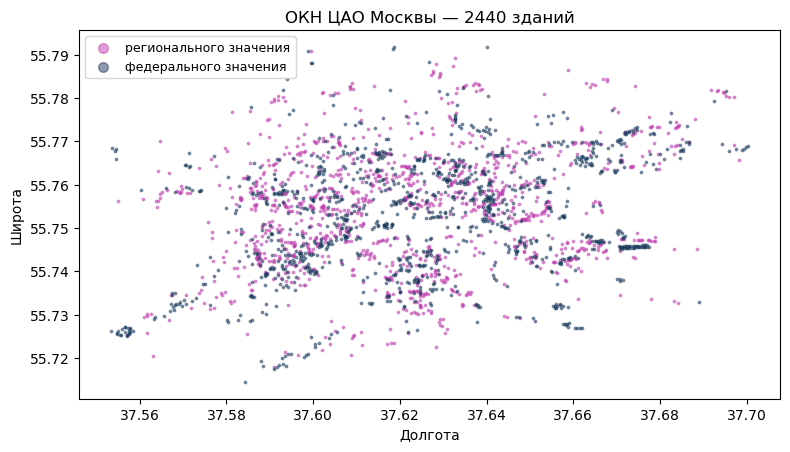

In [31]:
# scatter plot точек — грубая визуальная проверка, что все точки в ЦАО
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

colors = {'федерального значения': '#1A3A5C', 'регионального значения': "#BF3DAE"}
for cat, group in df.groupby('category'):
    ax.scatter(group['lon'], group['lat'], 
               c=colors.get(cat, 'gray'), s=3, alpha=0.5, label=cat)

ax.set_aspect('equal')
ax.legend(markerscale=4, fontsize=9)
ax.set_title(f'ОКН ЦАО Москвы — {len(df)} зданий', fontsize=12)
ax.set_xlabel('Долгота')
ax.set_ylabel('Широта')
plt.tight_layout()
plt.show()

## 9. Маппинг категорий для карты

In [32]:
# короткие метки и цвета для Mapbox
category_map = {
    'федерального значения': {'label': 'Федеральный', 'color': '#1A3A5C'},
    'регионального значения': {'label': 'Региональный', 'color': '#3D7ABF'},
}

df['category_label'] = df['category'].map(lambda x: category_map[x]['label'])
df['category_color'] = df['category'].map(lambda x: category_map[x]['color'])

print(df['category_label'].value_counts())

category_label
Региональный    1265
Федеральный     1175
Name: count, dtype: int64


## 10. Экспорт GeoJSON

Два файла:  
- **polygons** — building footprints для fill-extrusion слоя  
- **points** — центроиды для кластеризации и попапов

In [33]:
export_cols = ['name', 'name_short', 'address', 'category', 
               'category_label', 'district', 'global_id', 'lat', 'lon']

os.makedirs('../processed', exist_ok=True)

# --- Polygons GeoJSON ---
gdf_poly = gpd.GeoDataFrame(df[export_cols], geometry=df['geometry'], crs='EPSG:4326')
gdf_poly.to_file('../processed/okn-cao-polygons.geojson', driver='GeoJSON')

# --- Points GeoJSON ---
gdf_points = gpd.GeoDataFrame(df[export_cols], geometry=df['centroid'], crs='EPSG:4326')
gdf_points.to_file('../processed/okn-cao-points.geojson', driver='GeoJSON')

poly_size = os.path.getsize('../processed/okn-cao-polygons.geojson') / 1024 / 1024
pts_size = os.path.getsize('../processed/okn-cao-points.geojson') / 1024 / 1024
print(f'okn-cao-polygons.geojson: {poly_size:.1f} МБ')
print(f'okn-cao-points.geojson:   {pts_size:.1f} МБ')
print(f'\nЗаписей: {len(gdf_poly)}')

okn-cao-polygons.geojson: 2.7 МБ
okn-cao-points.geojson:   1.3 МБ

Записей: 2440


## 11. Итоговая статистика

In [ ]:
print(f'Всего зданий ОКН в ЦАО: {len(df)}')
print(f'\nПо категориям:')
print(df['category_label'].value_counts().to_string())
print(f'\nПо районам:')
print(df['district'].value_counts().to_string())
print(f'\nФайлы:')
print(f'  data/processed/okn-cao-polygons.geojson ({poly_size:.1f} МБ)')
print(f'  data/processed/okn-cao-points.geojson ({pts_size:.1f} МБ)')

Всего зданий ОКН в ЦАО: 2440

По категориям:
category_label
Региональный    1265
Федеральный     1175

По районам:
district
Басманный         458
Хамовники         340
Тверской          330
Таганский         312
Пресненский       259
Якиманка          189
Замоскворечье     165
Арбат             152
Мещанский         131
Красносельский    104

Файлы:
  data/processed/okn-cao-polygons.geojson (2.7 МБ)
  data/processed/okn-cao-points.geojson (1.3 МБ)
